In [7]:
import os
os.chdir(r"C:\Users\mattc\OneDrive\Documents\eso8GKofnumUkahs")
os.getcwd()

'C:\\Users\\mattc\\OneDrive\\Documents\\eso8GKofnumUkahs'

In [6]:
import numpy as np
import pandas as pd
from IPython.display import display, Markdown
from matplotlib import pyplot as plt
from sklearn.neighbors import KNeighborsClassifier
from itertools import combinations
from sklearn.model_selection import GridSearchCV, train_test_split
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, accuracy_score, precision_score, recall_score, f1_score, classification_report, make_scorer

from src.data.prepare_data import x_y_split, tt_split

In [7]:
random_state = 42
np.random.seed(random_state)

In [8]:
data = pd.read_csv('data/raw/ACME-HappinessSurvey2020.csv')
x, y = x_y_split(data)

### KNN Classifier Report

Best Parameters:
{'metric': 'manhattan', 'n_neighbors': 10, 'weights': 'uniform'}
Testing Data Accuracy:
0.62
              precision    recall  f1-score   support

           0       0.75      0.25      0.38        12
           1       0.59      0.93      0.72        14

    accuracy                           0.62        26
   macro avg       0.67      0.59      0.55        26
weighted avg       0.66      0.62      0.56        26



### Confusion Matrix

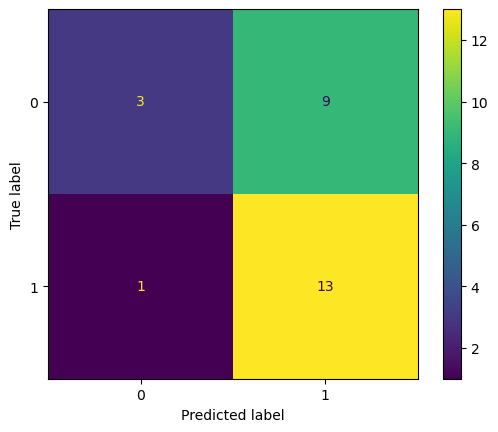

In [10]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42, stratify=y)

param_grid = {
    'n_neighbors': [1, 2, 3, 5, 7, 10, 12, 15, 20],
    'weights': ['uniform', 'distance'],
    'metric': ['euclidean', 'manhattan']
}

knn_grid = GridSearchCV(
    KNeighborsClassifier(),
    param_grid,
    cv=5, 
    scoring='balanced_accuracy',
    n_jobs=-1
)

knn_grid.fit(x_train, y_train)
knn_model = knn_grid.best_estimator_

y_pred = knn_model.predict(x_test)

display(Markdown('### KNN Classifier Report'))

print('Best Parameters:')
print(knn_grid.best_params_)

print('Testing Data Accuracy:')
print(round(accuracy_score(y_test, y_pred), 2))

print(classification_report(y_test, y_pred))

display(Markdown('### Confusion Matrix'))

ConfusionMatrixDisplay.from_predictions(y_test, y_pred)
plt.show()

### x_drop

### KNN Classifier Report

Best Features:
['X1', 'X2', 'X5']
Feature Combination Table
       Features  Accuracy  n_features
0  (X1, X2, X5)     0.769           3
1  (X1, X3, X4)     0.769           3
2         (X1,)     0.731           1
3      (X1, X5)     0.731           2
4      (X1, X6)     0.731           2
Best Parameters:
{'metric': 'manhattan', 'n_neighbors': 10, 'weights': 'uniform'}
Testing Data Accuracy:
0.77
              precision    recall  f1-score   support

           0       0.88      0.58      0.70        12
           1       0.72      0.93      0.81        14

    accuracy                           0.77        26
   macro avg       0.80      0.76      0.76        26
weighted avg       0.79      0.77      0.76        26



### Confusion Matrix

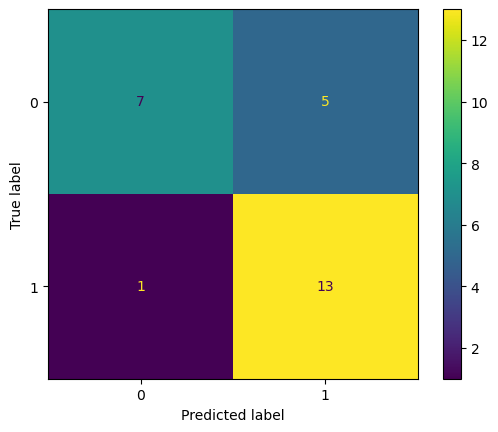

In [15]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42, stratify=y)
features = x.columns
results = {}

param_grid = {
    'n_neighbors': [1, 2, 3, 5, 7, 10, 12, 15, 20],
    'weights': ['uniform', 'distance'],
    'metric': ['euclidean', 'manhattan']
}

for r in range(1, len(features) + 1):
    for feature_subset in combinations(features, r):
        x_train_subset = x_train[list(feature_subset)]
        x_test_subset = x_test[list(feature_subset)]
        
        knn_grid = GridSearchCV(
            KNeighborsClassifier(),
            param_grid,
            cv=5, 
            scoring='balanced_accuracy',
            n_jobs=-1
        )
    
        knn_grid.fit(x_train_subset, y_train)
        knn_model = knn_grid.best_estimator_
    
        y_pred = knn_model.predict(x_test_subset)

        results[feature_subset] = round(accuracy_score(y_test, y_pred), 3)

results_df = pd.DataFrame(
    results.items(),
    columns=['Features', 'Accuracy']
)

results_df['n_features'] = results_df['Features'].apply(len)
results_df = results_df.sort_values(
    ['Accuracy', 'n_features'],
    ascending=[False, True]
).reset_index(drop=True)
best_features = list(results_df.iloc[0]['Features'])

knn_grid = GridSearchCV(
    KNeighborsClassifier(),
    param_grid,
    cv=5, 
    scoring='balanced_accuracy',
    n_jobs=-1
)

x_drop = x[best_features]
x_train_drop, x_test_drop, y_train, y_test = train_test_split(x_drop, y, test_size=0.2, random_state=42, stratify=y)

knn_grid.fit(x_train_drop, y_train)
knn_model = knn_grid.best_estimator_

y_pred = knn_model.predict(x_test_drop)

display(Markdown('### KNN Classifier Report'))

print('Best Features:')
print(best_features)

print('Feature Combination Table')
print(results_df.head(5))

print('Best Parameters:')
print(knn_grid.best_params_)

print('Testing Data Accuracy:')
print(round(accuracy_score(y_test, y_pred), 2))

print(classification_report(y_test, y_pred))

display(Markdown('### Confusion Matrix'))

ConfusionMatrixDisplay.from_predictions(y_test, y_pred)
plt.show()